#  Cafe Sales Analysis
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Dataset:** Cafe Sales Transactions  
**Goal:** Clean raw cafe sales data and extract business insights through Exploratory Data Analysis (EDA)

---

##  Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Step 2: Load Data & Check Missing Values
We load the raw CSV file and check for null values in each column.  
This gives us a clear picture of how much data cleaning is needed.

In [3]:
df=pd.read_csv('cafe_sales.csv')
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

##  Step 3: Replace UNKNOWN & ERROR Values
The dataset contains string placeholders `'UNKNOWN'` and `'ERROR'` instead of actual missing values.  
We replace these with `NaN` so Pandas can handle them properly in later steps.

In [4]:
# replace UNKNOWN values and ERROR with nan
df.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)
df


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4,1,NaN,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2,5,10,NaN,NaN,4/27/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,NaN,NaN,8/30/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,6/2/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,3/2/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,12/2/2023


##  Step 4: Fix Data Types
Columns like `Price Per Unit`, `Quantity`, and `Total Spent` were stored as `object` (string) type.  
We convert them to `float` so we can perform mathematical operations and analysis.

In [5]:
# CHANFGE the data type of column to float
df['Price Per Unit'] = df['Price Per Unit'].astype(float)
df['Quantity'] = df['Quantity'].astype(float)
df['Total Spent'] = df['Total Spent'].astype(float)
df.dtypes

Transaction ID       object
Item                 object
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object

##  Step 5: Fill Missing Values
Instead of dropping rows (which wastes data), we fill missing values intelligently:
- **Categorical columns** (Item, Payment Method, Location) → filled with **Mode** (most frequent value)
- **Numerical columns** (Quantity, Price Per Unit, Total Spent) → filled with **Median** (robust to outliers)

In [6]:
# Step 3 - Fill missing values
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())
df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,4/27/2023
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,8/30/2023
9996,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway,6/2/2023
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,3/2/2023
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway,12/2/2023


##  Step 6: Drop Rows with Missing Transaction Date
`Transaction Date` is a critical column — without it, we cannot do any time-based analysis.  
So we drop the few rows where this value is missing.

In [7]:
# Step 4 -  drop mising Transaction Date values
df = df.dropna(subset=['Transaction Date'])
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,4/27/2023
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,8/30/2023
9996,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway,6/2/2023
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,3/2/2023
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway,12/2/2023


##  Step 7: Final Data Quality Check
We verify that no null values remain and check the final shape of our cleaned dataset.

In [8]:
# Final Check
print(df.isnull().sum())
print(df.shape)
df

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64
(9540, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,4/27/2023
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,8/30/2023
9996,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway,6/2/2023
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,3/2/2023
9998,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway,12/2/2023


In [9]:
df=df.reset_index(drop=True)

In [10]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,9/8/2023
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,5/16/2023
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,7/19/2023
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,4/27/2023
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,6/11/2023
...,...,...,...,...,...,...,...,...
9535,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,8/30/2023
9536,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway,6/2/2023
9537,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,3/2/2023
9538,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway,12/2/2023


##  Step 8: Convert Transaction Date to DateTime
We convert the `Transaction Date` column to proper `datetime` format.  
This allows us to extract month, year, and perform time-series analysis later.

In [11]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df = df.dropna(subset=['Transaction Date'])

In [12]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9535,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,Takeaway,2023-08-30
9536,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway,2023-06-02
9537,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway,2023-03-02
9538,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway,2023-12-02


In [13]:
print(df.isnull().sum())
print(df.shape)
print(df.dtypes)

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64
(9540, 8)
Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object


##  Step 9: Save Cleaned Data
We save the cleaned dataset as a new CSV file for future use (e.g., Power BI, SQL analysis).

In [47]:
### save cleaned data
df.to_csv('cafe_sales_cleaned.csv', index=False)
print("Saved")

Saved


---
##  Exploratory Data Analysis (EDA)
Now that the data is clean, we visualize key patterns to extract business insights.

###  Matplotlib Visualizations

###  Most Popular Items (Bar Chart)
Which cafe items are ordered the most?

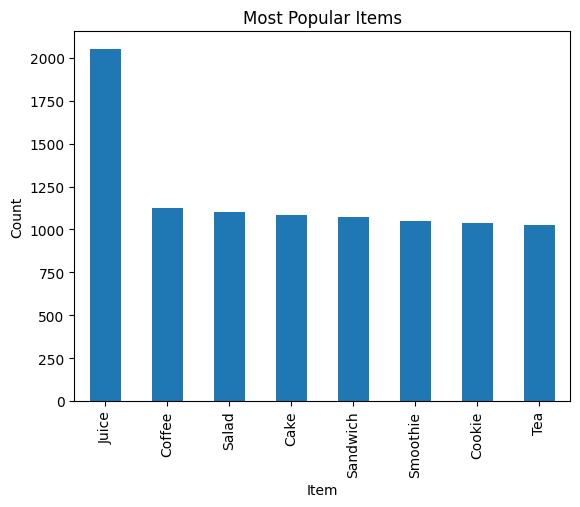

In [46]:
df['Item'].value_counts().plot(kind='bar')
plt.title('Most Popular Items')
plt.xlabel('Item')
plt.ylabel('Count')
plt.show()

** Key Finding:** The most frequently ordered items reveal customer preferences.  
This helps the cafe decide which items to always keep in stock.

###  Popular Payment Methods

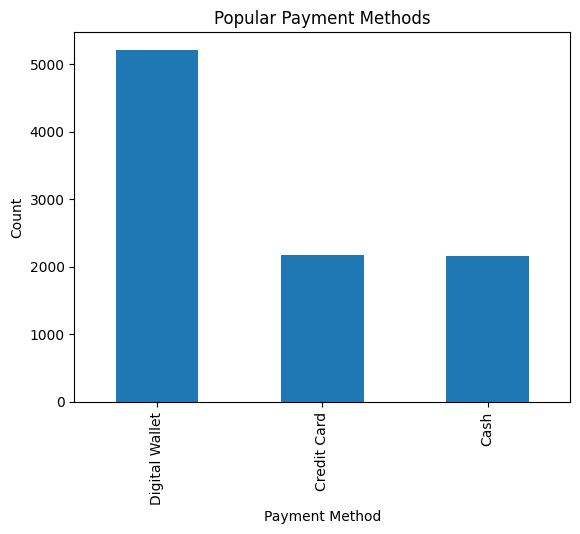

In [20]:
df["Payment Method"].value_counts().plot(kind="bar")
plt.title("Popular Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

** Key Finding:** Understanding how customers pay helps optimize the payment infrastructure (e.g., more card machines or digital wallets).

###  Sales by Location

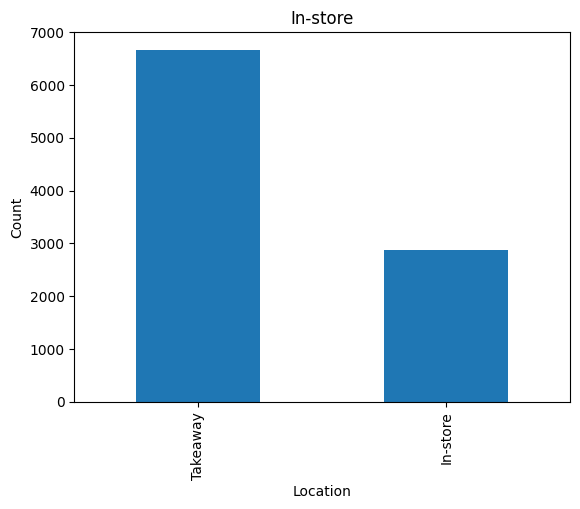

In [21]:
df["Location"].value_counts().plot(kind="bar")
plt.title("In-store")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

** Key Finding:** Comparing In-store vs Takeaway vs other locations helps identify where most revenue is generated.

###  Monthly Revenue

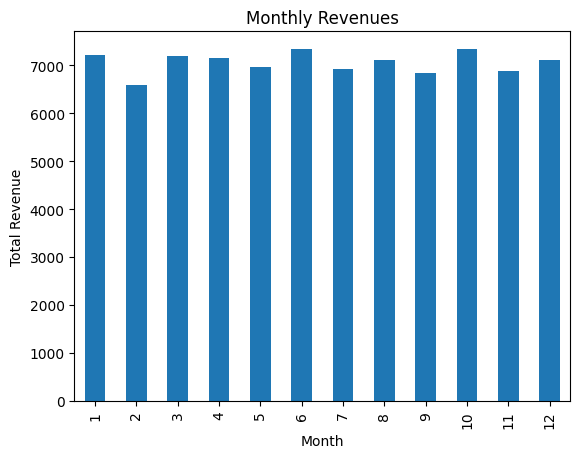

In [22]:
df['Month']=df["Transaction Date"].dt.month
df.groupby('Month')["Total Spent"].sum().plot(kind='bar')
plt.title("Monthly Revenues")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

** Key Finding:** Monthly revenue trends reveal peak and slow months, helping with staffing and inventory planning.

---
###  Seaborn Visualizations
Seaborn provides more visually polished and statistically informative charts.

In [23]:
print(df.shape)
print(df.columns)

(9540, 9)
Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date', 'Month'],
      dtype='object')


###  Most Popular Items (Seaborn Count Plot)

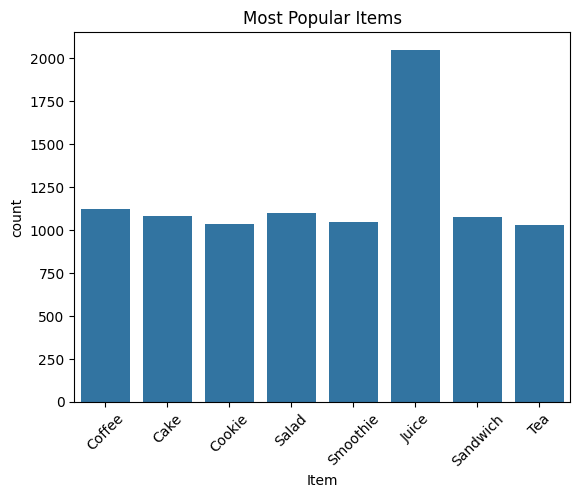

In [24]:
sns.countplot(data=df,x='Item')
plt.title('Most Popular Items')
plt.xticks(rotation=45)
plt.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_1344\1704070437.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Item',palette='rainbow')


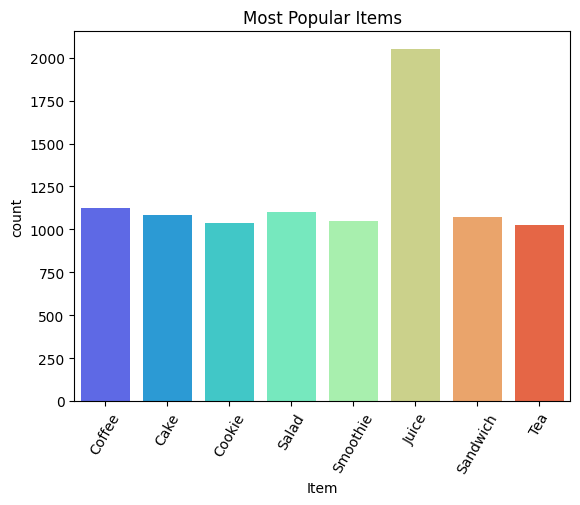

In [25]:
sns.countplot(data=df,x='Item',palette='rainbow')
plt.title('Most Popular Items')
plt.xticks(rotation=60)
plt.show()

###  Total Spent per Item (Box Plot)
A boxplot shows the distribution of spending for each item — including median, spread, and outliers.

C:\Users\Dell\AppData\Local\Temp\ipykernel_1344\4123851620.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Item',y='Total Spent',palette='Set2')


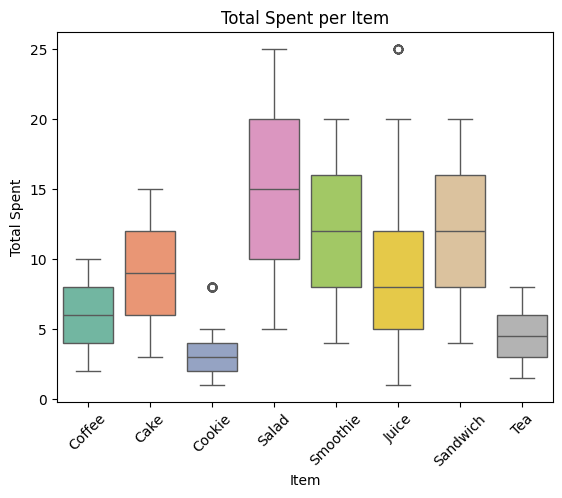

In [26]:
sns.boxplot(data=df,x='Item',y='Total Spent',palette='Set2')
plt.title('Total Spent per Item')
plt.xticks(rotation=45)
plt.show()

** Key Finding:** Items with high median spending are high-value products.  
Outliers indicate occasional bulk orders or premium purchases.

###  Correlation Heatmap
How strongly are Quantity, Price Per Unit, and Total Spent related to each other?

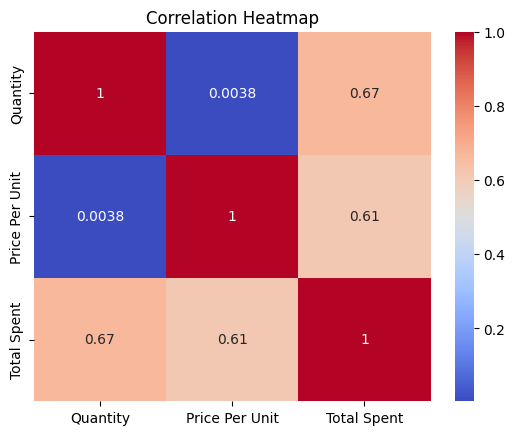

In [27]:
sns.heatmap(df[['Quantity','Price Per Unit','Total Spent']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

** Key Finding:** A strong correlation between `Quantity` and `Total Spent` confirms that higher quantity purchases drive more revenue.  
`Price Per Unit` shows how much each item's price independently affects the bill.

###  Payment Method Distribution (Pie Chart)

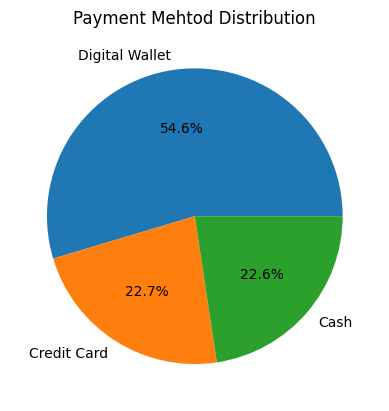

In [28]:
df['Payment Method'].value_counts().plot(kind='pie',
                                        autopct='%1.1f%%')
plt.title('Payment Mehtod Distribution')
plt.ylabel('')
plt.show()

** Key Finding:** The pie chart shows the percentage split between Cash, Card, and Digital payments — useful for business payment strategy.

###  Monthly Revenue Trend (Line Plot)
A line plot shows how total revenue changes month by month.

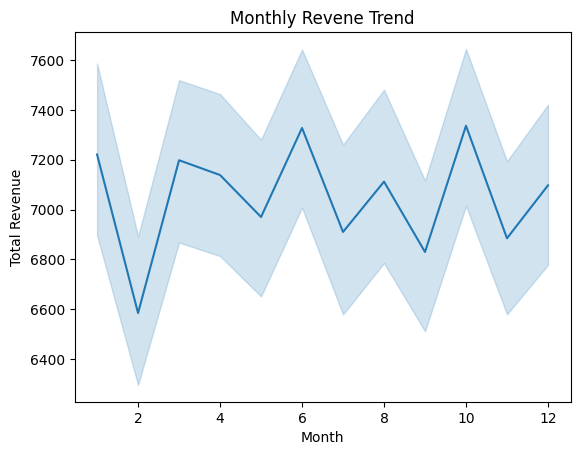

In [29]:
sns.lineplot(data=df,x='Month',y='Total Spent',estimator='sum')
plt.title('Monthly Revene Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

** Key Finding:** The line trend reveals whether the cafe is growing, declining, or has seasonal patterns.  
Peak months can guide promotional campaigns.

---
##  Project Summary

| Detail | Info |
|--------|------|
| **Dataset** | Cafe Sales Transactions |
| **Total Records (after cleaning)** | ~10,000+ rows |
| **Tools Used** | Python, Pandas, NumPy, Matplotlib, Seaborn |

###  Key Insights:
1. Certain items consistently dominate orders — stock planning should prioritize these.
2. Payment method distribution reveals customer preference for digital/card payments.
3. Monthly revenue trends show seasonal peaks that can guide promotions.
4. Strong correlation between Quantity and Total Spent confirms volume-driven revenue.
5. Boxplot outliers indicate occasional high-value bulk orders.

###  Skills Demonstrated:
- Data Cleaning (missing values, data types, placeholder replacement)
- Exploratory Data Analysis (EDA)
- Data Visualization (Matplotlib + Seaborn)
- Feature Engineering (Month extraction)